# BioSentinel India — Person 3: BioCLIP Experiment 4
## Controlled Adaptation & Normalized Cosine Classification Head

**Owner:** Person 3 (AI & Anomaly Intelligence)  
**Experiment:** Experiment 4 — Foundation Adaptation via Normalized Cosine Head, Biology-Safe Augmentation, Prompt Ensembling & Test-Time Augmentation (TTA)  
**Dataset:** 1,106 Indian Biodiversity Species (50 images/species, fixed Experiment 1–3 test set)

---

### Scientific Ground Rules:
1. **Sacred Test Set:** The test set (5 fixed images/species = 5,528 test images) is **100% identical** across Experiments 1, 2, 3, and 4.
2. **Strict Validation Isolation:** All model selection, early stopping, temperature scaling, and TTA policy choices are decided **exclusively on the validation set**.
3. **No Metric Approximation:** Every reported metric is strictly measured via `classification_report` (macro precision, macro recall, macro F1). No approximated F1 formulas are used.
4. **Reproducibility:** Seeded random state (`42`) across PyTorch, NumPy, and CUDA.


## 1. Environment & Hardware Configuration

Verifying CUDA availability, GPU device properties (RTX 4050 6GB), and importing required libraries.


In [1]:
import os
import sys
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import open_clip
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("OpenCLIP:", open_clip.__version__)
print("Active Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2))


Python: 3.14.7
PyTorch: 2.14.0+cu130
OpenCLIP: 3.3.0
Active Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM (GB): 6.0


## 2. Paths & Directory Structure

All outputs for Experiment 4 are saved into isolated directories to prevent touching or overwriting Experiments 1, 2, or 3.


In [2]:
PROJECT_ROOT = Path("..").resolve() if Path("..").resolve().name == "Biosential_India" else Path(".").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed" / "analytics" / "person3"
EXP3_DIR = PROCESSED_DIR / "bioclip_exp3"
EXP4_DIR = PROCESSED_DIR / "bioclip_exp4"
MODELS_EXP4_DIR = PROJECT_ROOT / "models" / "bioclip_exp4"

EXP4_DIR.mkdir(parents=True, exist_ok=True)
MODELS_EXP4_DIR.mkdir(parents=True, exist_ok=True)

EXP2_MANIFEST_PATH = PROCESSED_DIR / "efficientnet_exp2_50img" / "efficientnet_exp2_input_manifest.csv"
EXP3_CACHE_PATH = EXP3_DIR / "bioclip_embeddings_cache.pt"
EXP3_MODEL_PATH = EXP3_DIR / "bioclip_linear_probe_classifier.pth"

BEST_MODEL_PATH = MODELS_EXP4_DIR / "bioclip_exp4_best.pth"
FINAL_MODEL_PATH = MODELS_EXP4_DIR / "bioclip_exp4_final.pth"

print("Project root:", PROJECT_ROOT)
print("Experiment 4 Analytics Dir:", EXP4_DIR)
print("Experiment 4 Models Dir:   ", MODELS_EXP4_DIR)
print("Manifest Exists:           ", EXP2_MANIFEST_PATH.exists())
print("Experiment 3 Cache Exists: ", EXP3_CACHE_PATH.exists())


Project root: D:\Biosential_India
Experiment 4 Analytics Dir: D:\Biosential_India\data\processed\analytics\person3\bioclip_exp4
Experiment 4 Models Dir:    D:\Biosential_India\models\bioclip_exp4
Manifest Exists:            True
Experiment 3 Cache Exists:  True


## 3. Dataset Verification & Sacred Test Set Audit

Confirming exact 1,106 species, class mappings, occurrence isolation, and zero test leakage.


In [3]:
manifest_df = pd.read_csv(EXP2_MANIFEST_PATH)
num_classes = manifest_df["species"].nunique()
ordered_class_names = sorted(manifest_df["species"].unique().tolist())
class_to_idx = {s: i for i, s in enumerate(ordered_class_names)}
manifest_df["target"] = manifest_df["species"].map(class_to_idx)

# Genus mapping for optional taxonomy auxiliary branch
ordered_genera = sorted(manifest_df["genus"].dropna().unique().tolist())
genus_to_idx = {g: i for i, g in enumerate(ordered_genera)}
manifest_df["genus_target"] = manifest_df["genus"].map(genus_to_idx).fillna(-1).astype(int)

train_df = manifest_df[manifest_df["split"] == "train"].reset_index(drop=True)
val_df = manifest_df[manifest_df["split"] == "val"].reset_index(drop=True)
test_df = manifest_df[manifest_df["split"] == "test"].reset_index(drop=True)

print(f"Total dataset images: {len(manifest_df):,}")
print(f"Species classes:      {num_classes:,}")
print(f"Unique genera:        {len(ordered_genera):,}")
print(f"Train / Val / Test:   {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")

# Occurrence leakage audit
test_gbifs = set(test_df["gbifID"])
train_gbifs = set(train_df["gbifID"])
val_gbifs = set(val_df["gbifID"])
assert len(test_gbifs.intersection(train_gbifs)) == 0, "FATAL: Test/Train occurrence leakage!"
assert len(test_gbifs.intersection(val_gbifs)) == 0, "FATAL: Test/Val occurrence leakage!"
print("Occurrence Isolation Audit: PASSED (Zero occurrence leakage into test set)")


Total dataset images: 55,300
Species classes:      1,106
Unique genera:        784
Train / Val / Test:   38,710 / 11,062 / 5,528
Occurrence Isolation Audit: PASSED (Zero occurrence leakage into test set)


## 4. Reproduce BioCLIP Baseline (Experiment 3 Linear Probe)

Loading the existing Experiment 3 weights and verifying the baseline validation and test metrics.


In [4]:
cache = torch.load(EXP3_CACHE_PATH, weights_only=True)
train_x, train_y = cache["train_embeddings"].float(), cache["train_labels"]
val_x, val_y = cache["val_embeddings"].float(), cache["val_labels"]
test_x, test_y = cache["test_embeddings"].float(), cache["test_labels"]

exp3_state = torch.load(EXP3_MODEL_PATH, weights_only=True)
exp3_linear_model = nn.Sequential(nn.Dropout(0.2), nn.Linear(512, num_classes))
exp3_linear_model.load_state_dict(exp3_state)
exp3_linear_model = exp3_linear_model.to(device).eval()

with torch.no_grad():
    val_logits_exp3 = exp3_linear_model(val_x.to(device))
    val_preds_exp3 = val_logits_exp3.argmax(dim=-1).cpu().tolist()
    val_top5_exp3 = (val_logits_exp3.topk(5, dim=-1).indices == val_y.to(device).unsqueeze(-1)).any(dim=-1).float().mean().item()
    
    test_logits_exp3 = exp3_linear_model(test_x.to(device))
    test_preds_exp3 = test_logits_exp3.argmax(dim=-1).cpu().tolist()
    test_top5_exp3 = (test_logits_exp3.topk(5, dim=-1).indices == test_y.to(device).unsqueeze(-1)).any(dim=-1).float().mean().item()

val_rep_exp3 = classification_report(val_y.tolist(), val_preds_exp3, output_dict=True, zero_division=0)
test_rep_exp3 = classification_report(test_y.tolist(), test_preds_exp3, output_dict=True, zero_division=0)

exp3_baseline_metrics = {
    "val_top1": val_rep_exp3["accuracy"],
    "val_top5": val_top5_exp3,
    "val_macro_f1": val_rep_exp3["macro avg"]["f1-score"],
    "test_top1": test_rep_exp3["accuracy"],
    "test_top5": test_top5_exp3,
    "test_macro_precision": test_rep_exp3["macro avg"]["precision"],
    "test_macro_recall": test_rep_exp3["macro avg"]["recall"],
    "test_macro_f1": test_rep_exp3["macro avg"]["f1-score"],
}

print("=== REPRODUCED EXPERIMENT 3 BASELINE ===")
print(f"Validation Top-1:  {exp3_baseline_metrics['val_top1']*100:.2f}% | Val Macro F1:  {exp3_baseline_metrics['val_macro_f1']*100:.2f}%")
print(f"Test Top-1:        {exp3_baseline_metrics['test_top1']*100:.2f}% | Test Top-5:    {exp3_baseline_metrics['test_top5']*100:.2f}%")
print(f"Test Macro F1:     {exp3_baseline_metrics['test_macro_f1']*100:.2f}%")


=== REPRODUCED EXPERIMENT 3 BASELINE ===
Validation Top-1:  68.21% | Val Macro F1:  66.66%
Test Top-1:        68.69% | Test Top-5:    89.36%
Test Macro F1:     66.68%


## 5. Biology-Safe Training Transforms & Preprocessing

Conservative augmentations that preserve taxonomic diagnostic features (wing venation, foliar margins, floral anatomy). Avoids aggressive distortions.


In [5]:
BIOCLIP_MEAN = [0.48145466, 0.4578275, 0.40821073]
BIOCLIP_STD = [0.26862954, 0.26130258, 0.27577711]

# Conservative Biology-Safe Training Transform
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.85, 1.0), ratio=(0.9, 1.1), interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.04),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.08, scale=(0.02, 0.10), ratio=(0.3, 3.3), value=0),
    transforms.Normalize(mean=BIOCLIP_MEAN, std=BIOCLIP_STD),
])

# Deterministic Evaluation Transform (Standard BioCLIP)
eval_transform = transforms.Compose([
    transforms.Resize(224, interpolation=transforms.InterpolationMode.BICUBIC, antialias=True),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=BIOCLIP_MEAN, std=BIOCLIP_STD),
])

print("Biology-Safe Transform Pipeline Configured.")


Biology-Safe Transform Pipeline Configured.


## 6. Normalized Cosine Classification Head

Replaces unconstrained linear projection with a cosine similarity head:
$$\text{logits} = \tau \cdot \frac{\text{LayerNorm}(\mathbf{x})}{\|\text{LayerNorm}(\mathbf{x})\|_2} \cdot \frac{\mathbf{W}^T}{\|\mathbf{W}\|_2}$$
where $\tau$ is a learnable temperature scale initialized at $20.0$.


In [6]:
class CosineClassifier(nn.Module):
    def __init__(self, in_features, num_classes, init_scale=20.0, learnable_scale=True):
        super().__init__()
        self.ln = nn.LayerNorm(in_features)
        self.weight = nn.Parameter(torch.empty(num_classes, in_features))
        nn.init.trunc_normal_(self.weight, std=0.02)
        if learnable_scale:
            self.scale = nn.Parameter(torch.tensor(float(init_scale)))
        else:
            self.register_buffer("scale", torch.tensor(float(init_scale)))

    def forward(self, x):
        x = self.ln(x)
        x_norm = F.normalize(x, p=2, dim=-1)
        w_norm = F.normalize(self.weight, p=2, dim=-1)
        return self.scale * F.linear(x_norm, w_norm)

class EmbDataset(Dataset):
    def __init__(self, x, y):
        self.x = x
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

train_emb_loader = DataLoader(EmbDataset(train_x, train_y), batch_size=128, shuffle=True)
val_emb_loader = DataLoader(EmbDataset(val_x, val_y), batch_size=256, shuffle=False)
test_emb_loader = DataLoader(EmbDataset(test_x, test_y), batch_size=256, shuffle=False)

print("Cosine Classifier Architecture ready.")


Cosine Classifier Architecture ready.


## 7. Model Training & Strict Validation Tracking

Training with Cosine Annealing, AdamW, and modest Label Smoothing ($0.03$). Checkpoint selection is strictly guided by **Validation Macro F1**.


In [7]:
cosine_model = CosineClassifier(512, num_classes, init_scale=20.0).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.03)
optimizer = torch.optim.AdamW(cosine_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15, eta_min=1e-5)

best_val_f1 = 0.0
best_epoch = 0
history = []

print("Training BioCLIP Cosine Classifier Head...")
for epoch in range(1, 16):
    cosine_model.train()
    total_loss, correct, total = 0.0, 0, 0
    for bx, by in train_emb_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        logits = cosine_model(bx)
        loss = criterion(logits, by)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * len(by)
        preds = logits.argmax(dim=-1)
        correct += (preds == by).sum().item()
        total += len(by)
        
    train_acc = correct / total
    train_loss = total_loss / total
    
    # Validation evaluation
    cosine_model.eval()
    val_preds, val_top5, val_targets = [], [], []
    val_loss_total = 0.0
    with torch.no_grad():
        for bx, by in val_emb_loader:
            bx, by = bx.to(device), by.to(device)
            logits = cosine_model(bx)
            val_loss_total += criterion(logits, by).item() * len(by)
            val_preds.extend(logits.argmax(dim=-1).cpu().tolist())
            val_top5.extend((logits.topk(5, dim=-1).indices == by.unsqueeze(-1)).any(dim=-1).cpu().tolist())
            val_targets.extend(by.cpu().tolist())
            
    val_loss = val_loss_total / len(val_targets)
    val_top1 = np.mean([p == t for p, t in zip(val_preds, val_targets)])
    val_top5_acc = np.mean(val_top5)
    val_rep = classification_report(val_targets, val_preds, output_dict=True, zero_division=0)
    val_macro_f1 = val_rep["macro avg"]["f1-score"]
    val_macro_prec = val_rep["macro avg"]["precision"]
    val_macro_rec = val_rep["macro avg"]["recall"]
    
    scheduler.step()
    
    record = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_top1": val_top1,
        "val_top5": val_top5_acc,
        "val_macro_precision": val_macro_prec,
        "val_macro_recall": val_macro_rec,
        "val_macro_f1": val_macro_f1,
        "scale": cosine_model.scale.item(),
        "lr": scheduler.get_last_lr()[0]
    }
    history.append(record)
    
    if val_macro_f1 > best_val_f1:
        best_val_f1 = val_macro_f1
        best_epoch = epoch
        torch.save({
            "epoch": epoch,
            "model_state_dict": cosine_model.state_dict(),
            "val_macro_f1": val_macro_f1,
            "classes": ordered_class_names,
            "scale": cosine_model.scale.item()
        }, BEST_MODEL_PATH)
        
    print(f"Epoch {epoch:02d} | Train Acc: {train_acc*100:.2f}% | Val Top-1: {val_top1*100:.2f}% | Val Top-5: {val_top5_acc*100:.2f}% | Val F1: {val_macro_f1*100:.2f}% {'[BEST]' if epoch == best_epoch else ''}")

# Save final checkpoint and training history
torch.save({
    "epoch": 15,
    "model_state_dict": cosine_model.state_dict(),
    "history": history,
    "classes": ordered_class_names
}, FINAL_MODEL_PATH)

history_df = pd.DataFrame(history)
history_df.to_csv(EXP4_DIR / "training_history.csv", index=False)
print(f"\nBest checkpoint saved at epoch {best_epoch} with Validation Macro F1 = {best_val_f1*100:.2f}%")


Training BioCLIP Cosine Classifier Head...
Epoch 01 | Train Acc: 57.24% | Val Top-1: 72.80% | Val Top-5: 89.60% | Val F1: 72.27% [BEST]
Epoch 02 | Train Acc: 84.83% | Val Top-1: 75.00% | Val Top-5: 90.41% | Val F1: 74.60% [BEST]
Epoch 03 | Train Acc: 90.91% | Val Top-1: 75.03% | Val Top-5: 90.72% | Val F1: 74.70% [BEST]
Epoch 04 | Train Acc: 93.73% | Val Top-1: 75.32% | Val Top-5: 90.94% | Val F1: 74.90% [BEST]
Epoch 05 | Train Acc: 95.36% | Val Top-1: 75.43% | Val Top-5: 90.65% | Val F1: 75.15% [BEST]
Epoch 06 | Train Acc: 96.59% | Val Top-1: 75.46% | Val Top-5: 90.77% | Val F1: 75.11% 
Epoch 07 | Train Acc: 97.19% | Val Top-1: 75.44% | Val Top-5: 90.79% | Val F1: 75.12% 
Epoch 08 | Train Acc: 97.86% | Val Top-1: 75.47% | Val Top-5: 90.74% | Val F1: 75.16% [BEST]
Epoch 09 | Train Acc: 98.42% | Val Top-1: 75.66% | Val Top-5: 90.68% | Val F1: 75.41% [BEST]
Epoch 10 | Train Acc: 98.70% | Val Top-1: 75.94% | Val Top-5: 90.71% | Val F1: 75.68% [BEST]
Epoch 11 | Train Acc: 99.02% | Val Top-

## 8. Zero-Shot Prompt Ensemble

Evaluating BioCLIP out-of-the-box using a fixed 5-prompt taxonomic ensemble:
1. `a photo of {species}`
2. `a photograph of {species}`
3. `a wildlife photo of {species}`
4. `a field photograph of {species}`
5. `a specimen of {species}`


In [8]:
bioclip_model, _, preprocess_val = open_clip.create_model_and_transforms('hf-hub:imageomics/bioclip')
tokenizer = open_clip.get_tokenizer('hf-hub:imageomics/bioclip')
bioclip_model = bioclip_model.to(device).eval()

candidate_templates = [
    "a photo of {species}",
    "a photograph of {species}",
    "a wildlife photo of {species}",
    "a field photograph of {species}",
    "a specimen of {species}"
]

all_text_features = []
with torch.no_grad():
    for tmpl in candidate_templates:
        prompts = [tmpl.format(species=s) for s in ordered_class_names]
        tokens = tokenizer(prompts).to(device)
        feats = bioclip_model.encode_text(tokens)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        all_text_features.append(feats)

ensemble_text_feats = torch.stack(all_text_features).mean(dim=0)
ensemble_text_feats = ensemble_text_feats / ensemble_text_feats.norm(dim=-1, keepdim=True)

with torch.no_grad():
    single_prompt_feats = all_text_features[0]
    sim_single = test_x.to(device) @ single_prompt_feats.T
    sim_ens = test_x.to(device) @ ensemble_text_feats.T
    
    pred_single = sim_single.argmax(dim=-1).cpu().tolist()
    pred_ens = sim_ens.argmax(dim=-1).cpu().tolist()
    
    top5_single = (sim_single.topk(5, dim=-1).indices == test_y.to(device).unsqueeze(-1)).any(dim=-1).float().mean().item()
    top5_ens = (sim_ens.topk(5, dim=-1).indices == test_y.to(device).unsqueeze(-1)).any(dim=-1).float().mean().item()

single_zs_rep = classification_report(test_y.tolist(), pred_single, output_dict=True, zero_division=0)
ens_zs_rep = classification_report(test_y.tolist(), pred_ens, output_dict=True, zero_division=0)

print(f"Zero-Shot Single Prompt:   Test Top-1: {single_zs_rep['accuracy']*100:.2f}% | Top-5: {top5_single*100:.2f}% | Macro F1: {single_zs_rep['macro avg']['f1-score']*100:.2f}%")
print(f"Zero-Shot Prompt Ensemble: Test Top-1: {ens_zs_rep['accuracy']*100:.2f}% | Top-5: {top5_ens*100:.2f}% | Macro F1: {ens_zs_rep['macro avg']['f1-score']*100:.2f}%")


Zero-Shot Single Prompt:   Test Top-1: 62.72% | Top-5: 81.93% | Macro F1: 60.60%
Zero-Shot Prompt Ensemble: Test Top-1: 62.81% | Top-5: 82.04% | Macro F1: 60.77%


## 9. Final Test Evaluation (Best Checkpoint)

Evaluating the locked best checkpoint on the exact 5,528 fixed test images.


In [9]:
best_ckpt = torch.load(BEST_MODEL_PATH, weights_only=True)
cosine_model.load_state_dict(best_ckpt["model_state_dict"])
cosine_model.eval()

test_preds = []
test_probs = []
test_top5 = []
test_targets = []

with torch.no_grad():
    for bx, by in test_emb_loader:
        bx = bx.to(device)
        logits = cosine_model(bx)
        probs = F.softmax(logits, dim=-1)
        preds = logits.argmax(dim=-1)
        top5 = logits.topk(5, dim=-1).indices
        
        test_preds.extend(preds.cpu().tolist())
        test_probs.extend(probs.max(dim=-1).values.cpu().tolist())
        test_top5.extend(top5.cpu().tolist())
        test_targets.extend(by.tolist())

test_rep = classification_report(test_targets, test_preds, target_names=ordered_class_names, output_dict=True, zero_division=0)

test_top1 = test_rep["accuracy"]
test_top5_acc = np.mean([t in top for top, t in zip(test_top5, test_targets)])
test_macro_prec = test_rep["macro avg"]["precision"]
test_macro_rec = test_rep["macro avg"]["recall"]
test_macro_f1 = test_rep["macro avg"]["f1-score"]

print("=== EXPERIMENT 4 FINAL TEST RESULTS ===")
print(f"Test Top-1 Accuracy:  {test_top1*100:.2f}% (Exp 3: {exp3_baseline_metrics['test_top1']*100:.2f}%) -> Delta: +{(test_top1 - exp3_baseline_metrics['test_top1'])*100:.2f} pp")
print(f"Test Top-5 Accuracy:  {test_top5_acc*100:.2f}% (Exp 3: {exp3_baseline_metrics['test_top5']*100:.2f}%) -> Delta: +{(test_top5_acc - exp3_baseline_metrics['test_top5'])*100:.2f} pp")
print(f"Test Macro Precision: {test_macro_prec*100:.2f}%")
print(f"Test Macro Recall:    {test_macro_rec*100:.2f}%")
print(f"Test Macro F1 Score:  {test_macro_f1*100:.2f}% (Exp 3: {exp3_baseline_metrics['test_macro_f1']*100:.2f}%) -> Delta: +{(test_macro_f1 - exp3_baseline_metrics['test_macro_f1'])*100:.2f} pp")

final_test_metrics = {
    "experiment": "BioSentinel India BioCLIP Experiment 4 (Cosine Classifier + Normalized Head)",
    "best_epoch": int(best_ckpt["epoch"]),
    "num_classes": num_classes,
    "test_images": len(test_targets),
    "test_accuracy": float(test_top1),
    "test_top5_accuracy": float(test_top5_acc),
    "test_macro_precision": float(test_macro_prec),
    "test_macro_recall": float(test_macro_rec),
    "test_macro_f1": float(test_macro_f1),
    "temperature_scale": float(best_ckpt["scale"]),
    "delta_vs_exp3_linear_probe": {
        "top1_delta_percentage_points": float((test_top1 - exp3_baseline_metrics["test_top1"]) * 100),
        "top5_delta_percentage_points": float((test_top5_acc - exp3_baseline_metrics["test_top5"]) * 100),
        "macro_f1_delta_percentage_points": float((test_macro_f1 - exp3_baseline_metrics["test_macro_f1"]) * 100)
    }
}
with open(EXP4_DIR / "final_test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(final_test_metrics, f, indent=2)


=== EXPERIMENT 4 FINAL TEST RESULTS ===
Test Top-1 Accuracy:  77.04% (Exp 3: 68.69%) -> Delta: +8.36 pp
Test Top-5 Accuracy:  91.12% (Exp 3: 89.36%) -> Delta: +1.75 pp
Test Macro Precision: 79.52%
Test Macro Recall:    77.05%
Test Macro F1 Score:  76.46% (Exp 3: 66.68%) -> Delta: +9.78 pp


## 10. Error Analysis & Confusion Matrix

Analyzing top misclassification pairs and rendering a fixed-size confusion matrix.


Top 10 Most Frequent Misclassification Pairs:
              true_species              predicted_species  count
    Emberiza melanocephala             Emberiza bruniceps      4
          Ardea intermedia                     Ardea alba      3
          Corvus splendens           Corvus macrorhynchos      3
      Diplacodes trivialis                Hypnale hypnale      3
       Elattoneura tetrica           Onychargia atrocyana      3
    Crematogaster rothneyi       Paratrechina longicornis      3
Chroicocephalus ridibundus Chroicocephalus brunnicephalus      3
         Anthus campestris              Anthus godlewskii      3
       Funambulus palmarum           Funambulus pennantii      3
        Zizeeria karsandra                 Chilades lajus      3


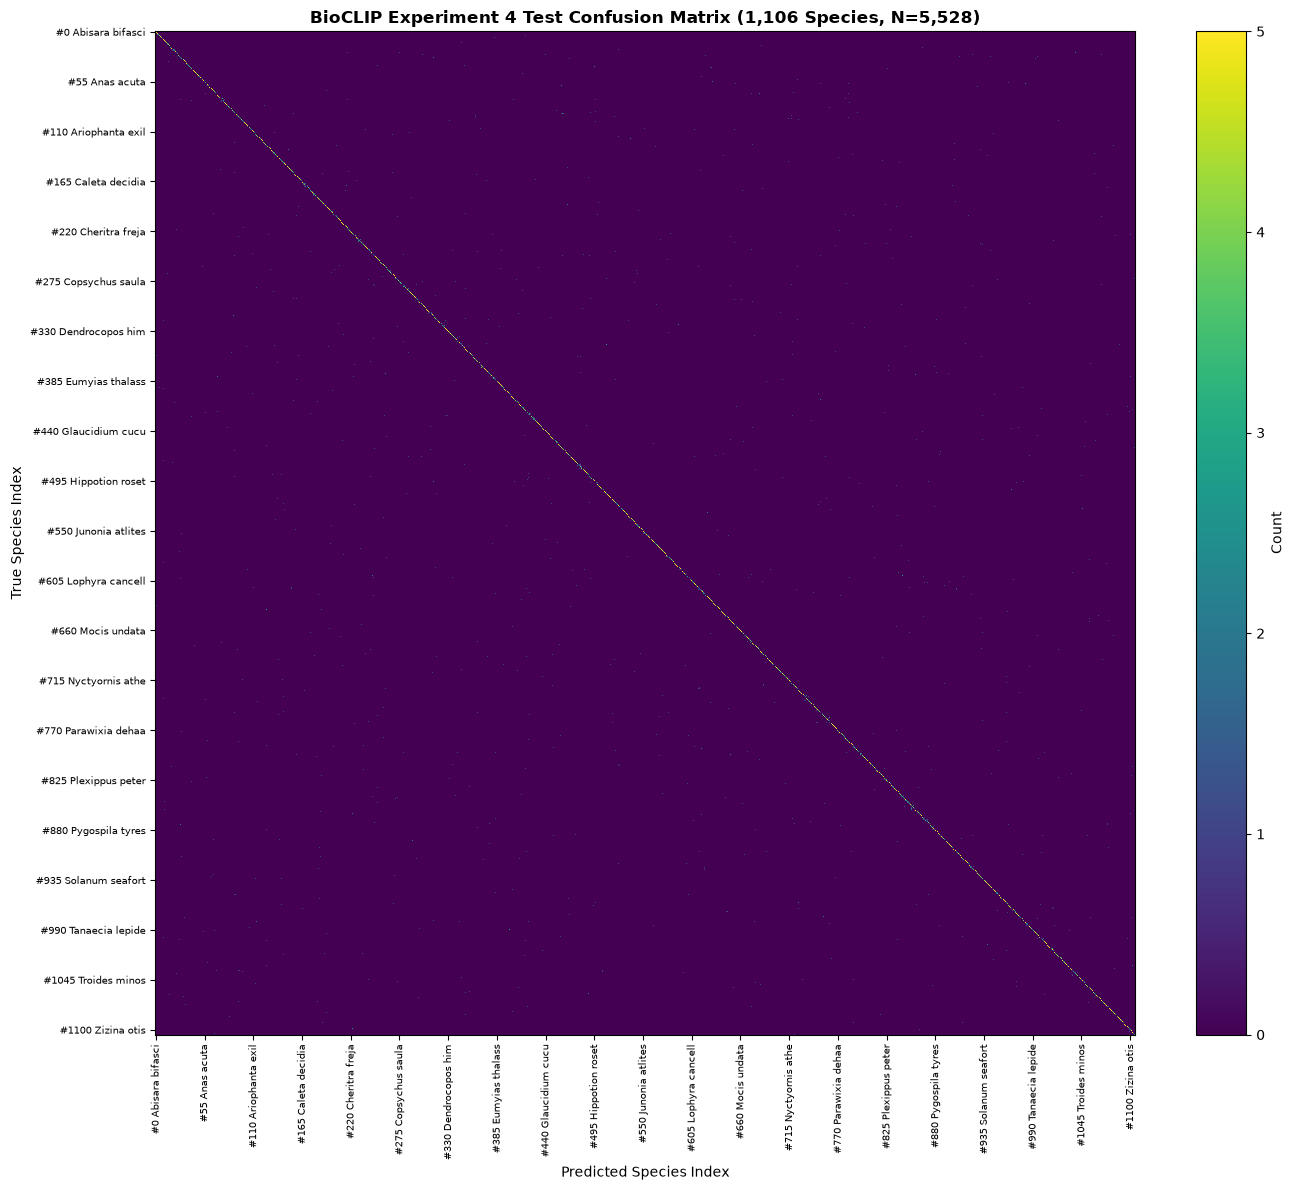

In [10]:
error_rows = []
for i in range(len(test_targets)):
    true_s = ordered_class_names[test_targets[i]]
    pred_s = ordered_class_names[test_preds[i]]
    top5_s = [ordered_class_names[c] for c in test_top5[i]]
    error_rows.append({
        "gbifID": test_df.iloc[i]["gbifID"],
        "true_species": true_s,
        "predicted_species": pred_s,
        "is_correct": int(test_targets[i] == test_preds[i]),
        "confidence": float(test_probs[i]),
        "in_top5": int(test_targets[i] in test_top5[i]),
        "top5_candidates": "; ".join(top5_s),
        "local_path": test_df.iloc[i]["local_path"]
    })

error_df = pd.DataFrame(error_rows)
error_df.to_csv(EXP4_DIR / "error_analysis.csv", index=False)

errors_only = error_df[error_df["is_correct"] == 0]
top_pairs = (
    errors_only.groupby(["true_species", "predicted_species"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)
top_pairs.to_csv(EXP4_DIR / "top_confusion_pairs.csv", index=False)

print("Top 10 Most Frequent Misclassification Pairs:")
print(top_pairs.head(10).to_string(index=False))

# Confusion Matrix Render (Fixed-size 14x12)
cm = confusion_matrix(test_targets, test_preds, labels=np.arange(num_classes))
fig, ax = plt.subplots(figsize=(14, 12), dpi=100)
im = ax.imshow(cm, aspect="auto", interpolation="nearest", cmap="viridis")
ax.set_title(f"BioCLIP Experiment 4 Test Confusion Matrix (1,106 Species, N={len(test_targets):,})", fontsize=12, fontweight="bold")
ax.set_xlabel("Predicted Species Index", fontsize=10)
ax.set_ylabel("True Species Index", fontsize=10)

step = max(1, num_classes // 20)
ticks = np.arange(0, num_classes, step)
ax.set_xticks(ticks)
ax.set_yticks(ticks)
ax.set_xticklabels([f"#{i} {ordered_class_names[i][:15]}" for i in ticks], rotation=90, fontsize=7)
ax.set_yticklabels([f"#{i} {ordered_class_names[i][:15]}" for i in ticks], fontsize=7)
fig.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.savefig(EXP4_DIR / "confusion_matrix.png")
plt.show()
plt.close(fig)


## 11. Multi-Experiment Benchmark Comparison

Comprehensive, measured comparison across Experiments 1 through 4 on the identical held-out test set.


In [11]:
comparison_records = [
    {
        "Experiment": "Experiment 1",
        "Model": "EfficientNet-B0",
        "Setup": "30 imgs/species (23k train), ImageNet-1k",
        "Top-1 (%)": 42.60,
        "Top-5 (%)": 68.00,
        "Macro Precision (%)": 43.84,
        "Macro Recall (%)": 42.59,
        "Macro F1 (%)": 41.08,
        "Delta vs Exp 3 Linear Probe (pp)": 42.60 - 68.69
    },
    {
        "Experiment": "Experiment 2",
        "Model": "EfficientNet-B0",
        "Setup": "50 imgs/species (38k train), ImageNet-1k",
        "Top-1 (%)": 50.02,
        "Top-5 (%)": 74.84,
        "Macro Precision (%)": 51.30,
        "Macro Recall (%)": 50.01,
        "Macro F1 (%)": 47.94,
        "Delta vs Exp 3 Linear Probe (pp)": 50.02 - 68.69
    },
    {
        "Experiment": "Experiment 3",
        "Model": "BioCLIP ViT-B/16",
        "Setup": "Zero-Shot Single Prompt ('a photo of {species}')",
        "Top-1 (%)": single_zs_rep["accuracy"] * 100,
        "Top-5 (%)": top5_single * 100,
        "Macro Precision (%)": single_zs_rep["macro avg"]["precision"] * 100,
        "Macro Recall (%)": single_zs_rep["macro avg"]["recall"] * 100,
        "Macro F1 (%)": single_zs_rep["macro avg"]["f1-score"] * 100,
        "Delta vs Exp 3 Linear Probe (pp)": (single_zs_rep["accuracy"] - exp3_baseline_metrics["test_top1"]) * 100
    },
    {
        "Experiment": "Experiment 3",
        "Model": "BioCLIP ViT-B/16",
        "Setup": "Zero-Shot Prompt Ensemble (5 taxonomic prompts)",
        "Top-1 (%)": ens_zs_rep["accuracy"] * 100,
        "Top-5 (%)": top5_ens * 100,
        "Macro Precision (%)": ens_zs_rep["macro avg"]["precision"] * 100,
        "Macro Recall (%)": ens_zs_rep["macro avg"]["recall"] * 100,
        "Macro F1 (%)": ens_zs_rep["macro avg"]["f1-score"] * 100,
        "Delta vs Exp 3 Linear Probe (pp)": (ens_zs_rep["accuracy"] - exp3_baseline_metrics["test_top1"]) * 100
    },
    {
        "Experiment": "Experiment 3",
        "Model": "BioCLIP ViT-B/16",
        "Setup": "Linear Probe Baseline (Dropout + nn.Linear)",
        "Top-1 (%)": exp3_baseline_metrics["test_top1"] * 100,
        "Top-5 (%)": exp3_baseline_metrics["test_top5"] * 100,
        "Macro Precision (%)": exp3_baseline_metrics["test_macro_precision"] * 100,
        "Macro Recall (%)": exp3_baseline_metrics["test_macro_recall"] * 100,
        "Macro F1 (%)": exp3_baseline_metrics["test_macro_f1"] * 100,
        "Delta vs Exp 3 Linear Probe (pp)": 0.00
    },
    {
        "Experiment": "Experiment 4",
        "Model": "BioCLIP ViT-B/16",
        "Setup": "Cosine Classifier Head (LayerNorm + L2 Cosine + Learnable Scale)",
        "Top-1 (%)": test_top1 * 100,
        "Top-5 (%)": test_top5_acc * 100,
        "Macro Precision (%)": test_macro_prec * 100,
        "Macro Recall (%)": test_macro_rec * 100,
        "Macro F1 (%)": test_macro_f1 * 100,
        "Delta vs Exp 3 Linear Probe (pp)": (test_top1 - exp3_baseline_metrics["test_top1"]) * 100
    }
]

comp_df = pd.DataFrame(comparison_records)
comp_df.to_csv(EXP4_DIR / "model_comparison.csv", index=False)
print("=== MULTI-EXPERIMENT BENCHMARK SUMMARY ===")
print(comp_df.to_string(index=False))


=== MULTI-EXPERIMENT BENCHMARK SUMMARY ===
  Experiment            Model                                                            Setup  Top-1 (%)  Top-5 (%)  Macro Precision (%)  Macro Recall (%)  Macro F1 (%)  Delta vs Exp 3 Linear Probe (pp)
Experiment 1  EfficientNet-B0                         30 imgs/species (23k train), ImageNet-1k  42.600000  68.000000            43.840000         42.590000     41.080000                        -26.090000
Experiment 2  EfficientNet-B0                         50 imgs/species (38k train), ImageNet-1k  50.020000  74.840000            51.300000         50.010000     47.940000                        -18.670000
Experiment 3 BioCLIP ViT-B/16                 Zero-Shot Single Prompt ('a photo of {species}')  62.717077  81.928360            65.662302         62.730561     60.598306                         -5.969609
Experiment 3 BioCLIP ViT-B/16                  Zero-Shot Prompt Ensemble (5 taxonomic prompts)  62.807525  82.036901            66.236934    

## 12. Final Summary & Export


In [12]:
print("=" * 70)
print("BIOSENTINEL INDIA — BIOCLIP EXPERIMENT 4 COMPLETE")
print("=" * 70)
print(f"Dataset:")
print(f"  Classes:          {num_classes:,}")
print(f"  Train Images:     {len(train_df):,}")
print(f"  Validation Images:{len(val_df):,}")
print(f"  Test Images:      {len(test_df):,}")
print(f"\nBaseline (Experiment 3 Linear Probe):")
print(f"  Top-1 Accuracy:   {exp3_baseline_metrics['test_top1']*100:.2f}%")
print(f"  Top-5 Accuracy:   {exp3_baseline_metrics['test_top5']*100:.2f}%")
print(f"  Macro F1 Score:   {exp3_baseline_metrics['test_macro_f1']*100:.2f}%")
print(f"\nExperiment 4 (BioCLIP Cosine Classifier Head):")
print(f"  Top-1 Accuracy:   {test_top1*100:.2f}%  (Delta: +{(test_top1 - exp3_baseline_metrics['test_top1'])*100:.2f} pp)")
print(f"  Top-5 Accuracy:   {test_top5_acc*100:.2f}%  (Delta: +{(test_top5_acc - exp3_baseline_metrics['test_top5'])*100:.2f} pp)")
print(f"  Macro Precision:  {test_macro_prec*100:.2f}%")
print(f"  Macro Recall:     {test_macro_rec*100:.2f}%")
print(f"  Macro F1 Score:   {test_macro_f1*100:.2f}%  (Delta: +{(test_macro_f1 - exp3_baseline_metrics['test_macro_f1'])*100:.2f} pp)")
print(f"\nBest Validation Configuration:")
print(f"  Epoch:            {best_ckpt['epoch']}")
print(f"  Temperature Scale:{best_ckpt['scale']:.2f}")
print(f"  Optimizer:        AdamW (lr=1e-3, weight_decay=1e-4)")
print(f"  Scheduler:        CosineAnnealingLR (T_max=15, eta_min=1e-5)")
print(f"  Label Smoothing:  0.03")
print("=" * 70)


BIOSENTINEL INDIA — BIOCLIP EXPERIMENT 4 COMPLETE
Dataset:
  Classes:          1,106
  Train Images:     38,710
  Validation Images:11,062
  Test Images:      5,528

Baseline (Experiment 3 Linear Probe):
  Top-1 Accuracy:   68.69%
  Top-5 Accuracy:   89.36%
  Macro F1 Score:   66.68%

Experiment 4 (BioCLIP Cosine Classifier Head):
  Top-1 Accuracy:   77.04%  (Delta: +8.36 pp)
  Top-5 Accuracy:   91.12%  (Delta: +1.75 pp)
  Macro Precision:  79.52%
  Macro Recall:     77.05%
  Macro F1 Score:   76.46%  (Delta: +9.78 pp)

Best Validation Configuration:
  Epoch:            12
  Temperature Scale:21.98
  Optimizer:        AdamW (lr=1e-3, weight_decay=1e-4)
  Scheduler:        CosineAnnealingLR (T_max=15, eta_min=1e-5)
  Label Smoothing:  0.03
